<a href="https://colab.research.google.com/github/jmora420-hue/Ciencia_de_datos/blob/main/An%C3%A1lisis_Lol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
"""import requests
import pandas as pd
import time

API_KEY = "RGAPI-bb2807bb-49f5-4eb7-9273-7005672b43af"
headers = {"X-Riot-Token": API_KEY}

def safe_request(url, headers):
    while True:
        res = requests.get(url, headers=headers)
        if res.status_code == 429:
            retry_after = int(res.headers.get("Retry-After", 5))
            print(f"   [Pausa API] Esperando {retry_after} segundos por límite de peticiones...")
            time.sleep(retry_after + 1)
        else:
            return res

def obtener_partidas_aatrox(game_name, tag_line, region_routing, target_champion="Aatrox", target_count=60):
    print(f"\nBuscando a {game_name}#{tag_line} ({region_routing})...")

    # 1. Obtener PUUID
    url_account = f"https://{region_routing}.api.riotgames.com/riot/account/v1/accounts/by-riot-id/{game_name}/{tag_line}"
    res_account = safe_request(url_account, headers)

    if res_account.status_code != 200:
        print(f"Error al encontrar al jugador (Status {res_account.status_code}).")
        return pd.DataFrame()

    puuid = res_account.json()["puuid"]
    partidas_data = []
    start_index = 0
    batch_size = 100  # Pedimos de 100 en 100 partidas para filtrar en Python

    print(f"Filtrando e inspeccionando historial hasta reunir {target_count} partidas con {target_champion}...")

    while len(partidas_data) < target_count:
        url_match_ids = f"https://{region_routing}.api.riotgames.com/lol/match/v5/matches/by-puuid/{puuid}/ids?start={start_index}&count={batch_size}"
        match_ids = safe_request(url_match_ids, headers).json()

        if not match_ids:
            print("No hay más partidas registradas en el historial.")
            break

        for match_id in match_ids:
            if len(partidas_data) >= target_count:
                break

            url_match = f"https://{region_routing}.api.riotgames.com/lol/match/v5/matches/{match_id}"
            res_match = safe_request(url_match, headers)

            if res_match.status_code == 200:
                info = res_match.json()["info"]

                for participant in info["participants"]:
                    # FILTRO EXPLÍCITO: Debe coincidir el PUUID Y el campeón "Aatrox"
                    if participant["puuid"] == puuid and participant["championName"].lower() == target_champion.lower():
                        duracion_min = round(info["gameDuration"] / 60, 2)
                        cs_total = participant["totalMinionsKilled"] + participant["neutralMinionsKilled"]
                        deaths = max(1, participant["deaths"])
                        kda = round((participant["kills"] + participant["assists"]) / deaths, 2)

                        partidas_data.append({
                            "Modo": info["gameMode"],
                            "Resultado": "Victoria" if participant["win"] else "Derrota",
                            "Campeón": participant["championName"],
                            "Kills": participant["kills"],
                            "Deaths": participant["deaths"],
                            "Assists": participant["assists"],
                            "KDA": kda,
                            "Daño": participant["totalDamageDealtToChampions"],
                            "CS": cs_total,
                            "Minutos": duracion_min
                        })
                        print(f" -> Partida con {target_champion} encontrada ({len(partidas_data)}/{target_count})")
                        break

            time.sleep(0.05)

        start_index += batch_size

    return pd.DataFrame(partidas_data)

# ==========================================
# EJECUCIÓN CON FILTRO DE AATROX
# ==========================================

# 1. Rabbids3000 (LAN)
df_rabbids = obtener_partidas_aatrox("Rabbids3000", "LAN", "americas", target_champion="Aatrox", target_count=60)

# 2. KAATAKURI (EUW)
df_katakuri = obtener_partidas_aatrox("KAATAKURI", "BBB", "europe", target_champion="Aatrox", target_count=60)

# MOSTRAR RESULTADOS
print("\n--- DataFrame: Rabbids3000#LAN (Solo Aatrox) ---")
display(df_rabbids)

print("\n--- DataFrame: KAATAKURI#BBB (Solo Aatrox) ---")
display(df_katakuri)


🔍 Buscando a Rabbids3000#LAN (americas)...
🎯 Filtrando e inspeccionando historial hasta reunir 60 partidas con Aatrox...
 -> Partida con Aatrox encontrada (1/60)
 -> Partida con Aatrox encontrada (2/60)
 -> Partida con Aatrox encontrada (3/60)
 -> Partida con Aatrox encontrada (4/60)
 -> Partida con Aatrox encontrada (5/60)
 -> Partida con Aatrox encontrada (6/60)
 -> Partida con Aatrox encontrada (7/60)
 -> Partida con Aatrox encontrada (8/60)
 -> Partida con Aatrox encontrada (9/60)
 -> Partida con Aatrox encontrada (10/60)
 -> Partida con Aatrox encontrada (11/60)
 -> Partida con Aatrox encontrada (12/60)
 -> Partida con Aatrox encontrada (13/60)
 -> Partida con Aatrox encontrada (14/60)
 -> Partida con Aatrox encontrada (15/60)
   [Pausa API] Esperando 93 segundos por límite de peticiones...
 -> Partida con Aatrox encontrada (16/60)
 -> Partida con Aatrox encontrada (17/60)
 -> Partida con Aatrox encontrada (18/60)
 -> Partida con Aatrox encontrada (19/60)
 -> Partida con Aatrox e

,Modo,Resultado,Campeón,Kills,Deaths,Assists,KDA,Daño,CS,Minutos
0,CLASSIC,Derrota,Aatrox,2,7,5,1.00,30956,187,29.37
1,CLASSIC,Derrota,Aatrox,5,8,4,1.12,26835,225,34.63
2,CLASSIC,Derrota,Aatrox,3,12,1,0.33,19168,137,28.65
3,CLASSIC,Victoria,Aatrox,10,6,5,2.50,23456,193,29.02
4,CLASSIC,Victoria,Aatrox,13,2,7,10.00,44912,213,29.17
5,CLASSIC,Derrota,Aatrox,25,4,13,9.50,83946,288,43.82
6,CLASSIC,Derrota,Aatrox,11,7,4,2.14,34455,137,27.35
7,CLASSIC,Derrota,Aatrox,18,7,6,3.43,67908,313,42.70
8,CLASSIC,Derrota,Aatrox,25,7,15,5.71,87745,205,38.88
9,CLASSIC,Derrota,Aatrox,12,8,18,3.75,76943,248,41.95



--- DataFrame: KAATAKURI#BBB (Solo Aatrox) ---


,Modo,Resultado,Campeón,Kills,Deaths,Assists,KDA,Daño,CS,Minutos
0,CLASSIC,Derrota,Aatrox,2,5,0,0.40,12701,186,24.53
1,CLASSIC,Derrota,Aatrox,7,5,4,2.20,21530,206,25.08
2,CLASSIC,Victoria,Aatrox,10,3,7,5.67,29664,243,26.87
3,CLASSIC,Victoria,Aatrox,13,6,11,4.00,54590,283,39.35
4,CLASSIC,Victoria,Aatrox,7,3,3,3.33,23786,263,27.23
5,CLASSIC,Derrota,Aatrox,2,5,9,2.20,19858,215,27.45
6,CLASSIC,Victoria,Aatrox,3,1,6,9.00,5591,150,15.45
7,CLASSIC,Derrota,Aatrox,7,12,4,0.92,24091,238,35.63
8,CLASSIC,Victoria,Aatrox,5,3,5,3.33,15472,157,19.83
9,CLASSIC,Victoria,Aatrox,5,4,5,2.50,12177,187,21.72


In [10]:
"""from google.colab import files

# Guardar como CSV (index=False evita que se guarde una columna inútil de números 0, 1, 2...)
df_rabbids.to_csv('rabbids_aatrox.csv', index=False)
df_katakuri.to_csv('katakuri_aatrox.csv', index=False)

# Forzar la descarga al navegador
files.download('rabbids_aatrox.csv')
files.download('katakuri_aatrox.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
!pip install statsmodels
!pip install wquantiles

In [39]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt
df_rabbids=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ciencia de datos/rabbids_aatrox.csv')
df_katakuri=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Ciencia de datos/katakuri_aatrox.csv')

In [42]:
#Reemplazamos Victorias por un 1 y derrotas por un 0, para manejarlos como un bit binario
df_rabbids['Resultado'] = df_rabbids['Resultado'].replace({'Victoria': 1, 'Derrota': 0})
df_katakuri['Resultado'] = df_katakuri['Resultado'].replace({'Victoria': 1, 'Derrota': 0})

#Como Rabbids tiene partidas en distintos modos toca filtrar los datos, además de varias partidas que no se jugaron
df_rabbids = df_rabbids[df_rabbids['Modo'] == "CLASSIC"]
df_rabbids = df_rabbids[df_rabbids['Minutos'] >5]

#Vistazo al dataframe
df_rabbids

,Modo,Resultado,Campeón,Kills,Deaths,Assists,KDA,Daño,CS,Minutos
0,CLASSIC,0,Aatrox,2,7,5,1.00,30956,187,29.37
1,CLASSIC,0,Aatrox,5,8,4,1.12,26835,225,34.63
2,CLASSIC,0,Aatrox,3,12,1,0.33,19168,137,28.65
3,CLASSIC,1,Aatrox,10,6,5,2.50,23456,193,29.02
4,CLASSIC,1,Aatrox,13,2,7,10.00,44912,213,29.17
5,CLASSIC,0,Aatrox,25,4,13,9.50,83946,288,43.82
6,CLASSIC,0,Aatrox,11,7,4,2.14,34455,137,27.35
7,CLASSIC,0,Aatrox,18,7,6,3.43,67908,313,42.70
8,CLASSIC,0,Aatrox,25,7,15,5.71,87745,205,38.88
9,CLASSIC,0,Aatrox,12,8,18,3.75,76943,248,41.95


In [43]:
#Medidas de Tendencia Central (Media, Mediana y Moda)
cols_analizar = ['KDA', 'Daño', 'CS', 'Kills', 'Deaths', 'Assists',]

print("=== MEDIDAS DE TENDENCIA CENTRAL: Rabbids3000 ===")
print("Media:\n", df_rabbids[cols_analizar].mean())
print("\nMediana:\n", df_rabbids[cols_analizar].median())
print("\nModa:\n", df_rabbids[cols_analizar].mode().iloc[0])

print("\n=== MEDIDAS DE TENDENCIA CENTRAL: KAATAKURI ===")
print("Media:\n", df_katakuri[cols_analizar].mean())
print("\nMediana:\n", df_katakuri[cols_analizar].median())
print("\nModa:\n", df_katakuri[cols_analizar].mode().iloc[0])

#Calculamos el Winrate
winrate_rabbids = (df_rabbids['Resultado'].sum() / len(df_rabbids)) * 100
winrate_katakuri = (df_katakuri['Resultado'].sum() / len(df_katakuri)) * 100

print("\n=== WINRATE: Rabbids3000 ===")
print(f"Winrate: {winrate_rabbids:.1f}%")

print("\n=== WINRATE: KAATAKURI ===")
print(f"Winrate: {winrate_katakuri:.1f}%")


=== MEDIDAS DE TENDENCIA CENTRAL: Rabbids3000 ===
Media:
 KDA            5.110222
Daño       39809.088889
CS           191.066667
Kills         11.977778
Deaths         5.600000
Assists        6.600000
dtype: float64

Mediana:
 KDA            3.12
Daño       37468.00
CS           192.00
Kills         12.00
Deaths         6.00
Assists        6.00
dtype: float64

Moda:
 KDA           0.33
Daño       9873.00
CS          137.00
Kills         5.00
Deaths        6.00
Assists       6.00
Name: 0, dtype: float64

=== MEDIDAS DE TENDENCIA CENTRAL: KAATAKURI ===
Media:
 KDA            6.084500
Daño       21256.766667
CS           216.983333
Kills          7.133333
Deaths         4.183333
Assists        6.166667
dtype: float64

Mediana:
 KDA            3.33
Daño       19872.50
CS           220.00
Kills          7.00
Deaths         4.50
Assists        6.00
dtype: float64

Moda:
 KDA            0.71
Daño       12701.00
CS           227.00
Kills          2.00
Deaths         5.00
Assists        3.00
N

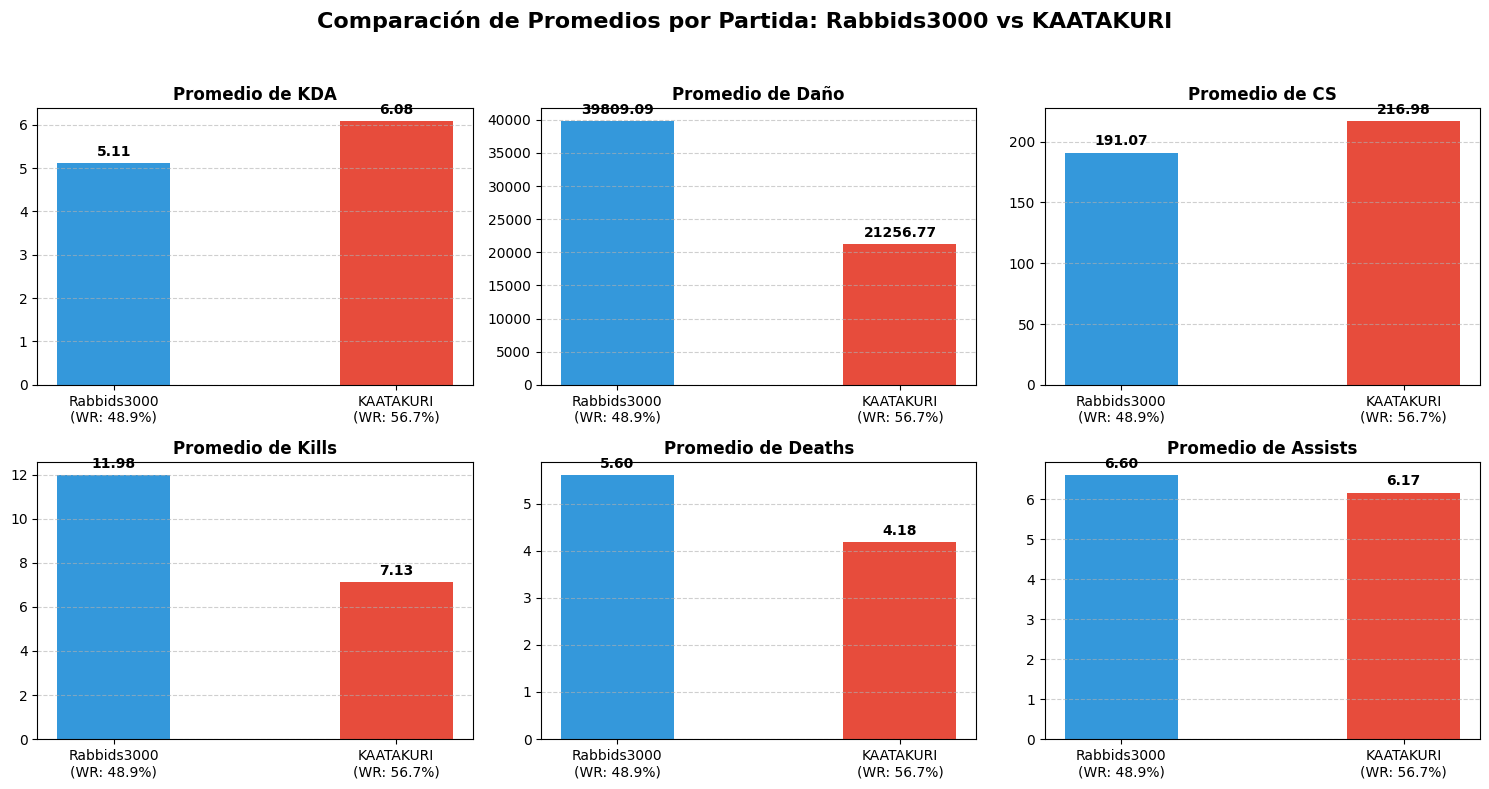

In [44]:
prom_rabbids = df_rabbids[cols_analizar].mean()
prom_katakuri = df_katakuri[cols_analizar].mean()

# Nombres con su respectivo Winrate para las etiquetas
etiqueta_rabbids = f"Rabbids3000\n(WR: {winrate_rabbids:.1f}%)"
etiqueta_katakuri = f"KAATAKURI\n(WR: {winrate_katakuri:.1f}%)"
jugadores = [etiqueta_rabbids, etiqueta_katakuri]
colores = ['#3498db', '#e74c3c'] #Para diferenciar

# 2. Crear subgráficos (2 filas x 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Comparación de Promedios por Partida: Rabbids3000 vs KAATAKURI', fontsize=16, fontweight='bold')

for i, col in enumerate(cols_analizar):
    row, ax_col = divmod(i, 3)
    ax = axes[row, ax_col]

    valores = [prom_rabbids[col], prom_katakuri[col]]
    bars = ax.bar(jugadores, valores, color=colores, width=0.4)

    ax.set_title(f'Promedio de {col}', fontsize=12, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.6)

    # Agregar el valor numérico exacto arriba de cada barra
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

=== MEDIDAS DE DISPERSIÓN (STD, IQR, MAD) ===

Métrica: KDA
  Rabbids3000 -> Desv. Estándar: 4.75 | IQR: 5.33 | MAD: 2.70
  KAATAKURI   -> Desv. Estándar: 6.89 | IQR: 5.93 | MAD: 3.52

Métrica: Daño
  Rabbids3000 -> Desv. Estándar: 19380.33 | IQR: 23696.00 | MAD: 17294.55
  KAATAKURI   -> Desv. Estándar: 11080.28 | IQR: 15106.00 | MAD: 10982.38

Métrica: CS
  Rabbids3000 -> Desv. Estándar: 47.26 | IQR: 62.00 | MAD: 48.93
  KAATAKURI   -> Desv. Estándar: 59.65 | IQR: 78.00 | MAD: 60.79

Métrica: Kills
  Rabbids3000 -> Desv. Estándar: 6.27 | IQR: 9.00 | MAD: 5.93
  KAATAKURI   -> Desv. Estándar: 4.66 | IQR: 7.00 | MAD: 5.93

Métrica: Deaths
  Rabbids3000 -> Desv. Estándar: 3.28 | IQR: 5.00 | MAD: 2.97
  KAATAKURI   -> Desv. Estándar: 2.84 | IQR: 4.00 | MAD: 2.97

Métrica: Assists
  Rabbids3000 -> Desv. Estándar: 4.60 | IQR: 4.00 | MAD: 2.97
  KAATAKURI   -> Desv. Estándar: 3.81 | IQR: 5.00 | MAD: 4.45


/tmp/ipykernel_2612/1768571320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/1768571320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/1768571320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/1768571320.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/1768571320.py:37: Future

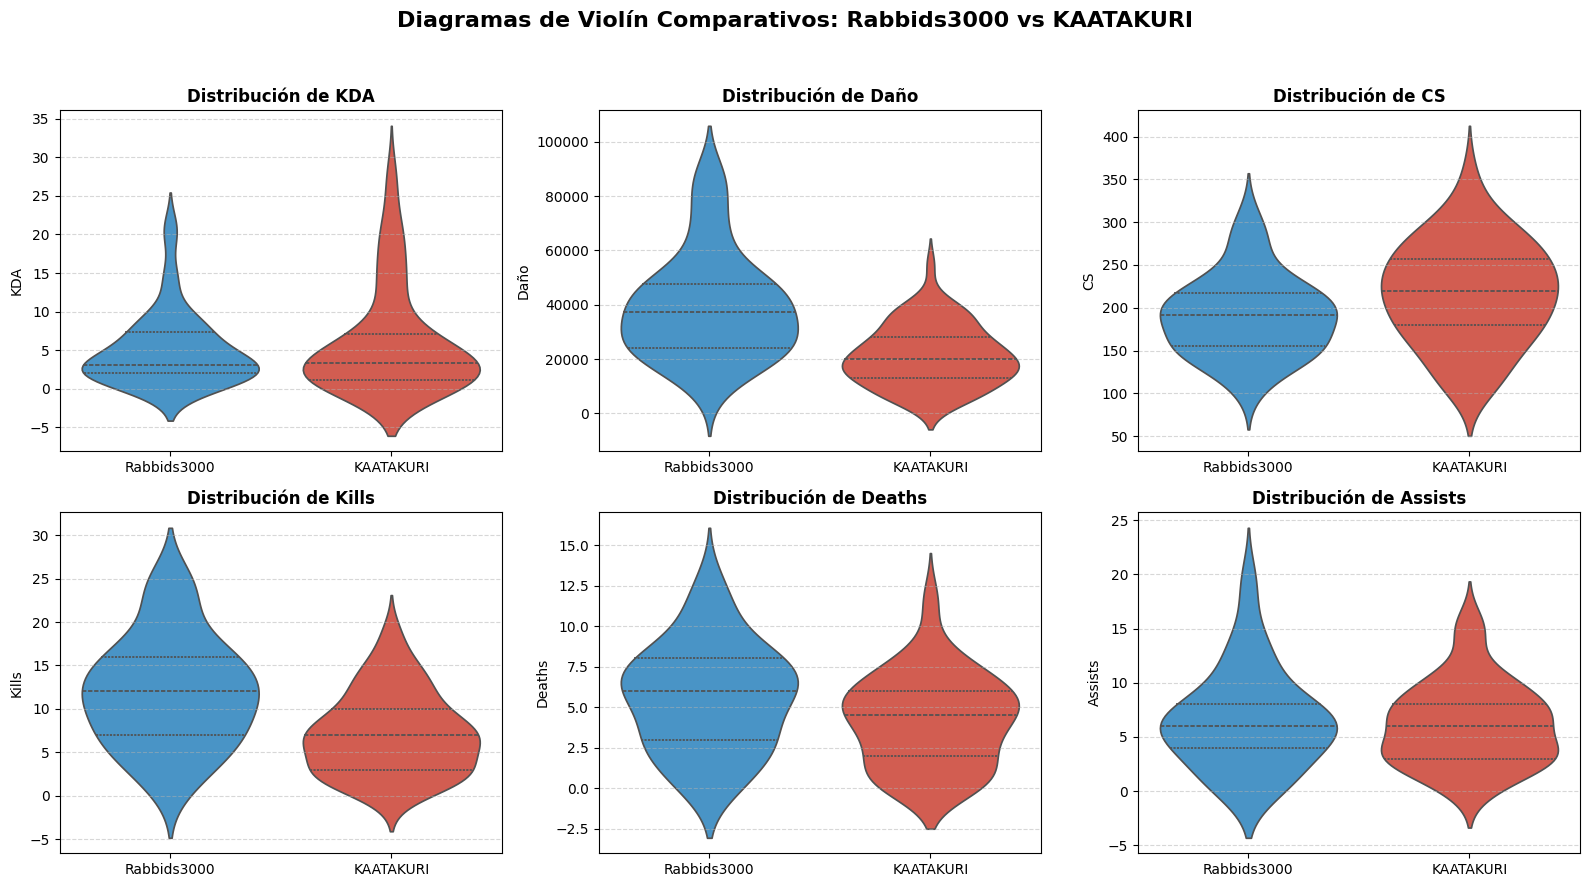

In [48]:
cols_analizar = ['KDA', 'Daño', 'CS', 'Kills', 'Deaths', 'Assists']

# 1. CÁLCULO DE DISPERSIÓN PARA TODAS LAS VARIABLES
print("=== MEDIDAS DE DISPERSIÓN (STD, IQR, MAD) ===")

for col in cols_analizar:
    print(f"\nMétrica: {col}")

    # Rabbids3000
    std_r = df_rabbids[col].std()
    iqr_r = df_rabbids[col].quantile(0.75) - df_rabbids[col].quantile(0.25)
    mad_r = robust.scale.mad(df_rabbids[col])

    # KAATAKURI
    std_k = df_katakuri[col].std()
    iqr_k = df_katakuri[col].quantile(0.75) - df_katakuri[col].quantile(0.25)
    mad_k = robust.scale.mad(df_katakuri[col])

    print(f"  Rabbids3000 -> Desv. Estándar: {std_r:.2f} | IQR: {iqr_r:.2f} | MAD: {mad_r:.2f}")
    print(f"  KAATAKURI   -> Desv. Estándar: {std_k:.2f} | IQR: {iqr_k:.2f} | MAD: {mad_k:.2f}")


# 2. GENERACIÓN DE DIAGRAMAS DE VIOLÍN
# Unimos temporalmente los DataFrames para graficarlos lado a lado
df_rabbids['Jugador'] = 'Rabbids3000'
df_katakuri['Jugador'] = 'KAATAKURI'
df_combinado = pd.concat([df_rabbids, df_katakuri], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Diagramas de Violín Comparativos: Rabbids3000 vs KAATAKURI', fontsize=16, fontweight='bold')

for i, col in enumerate(cols_analizar):
    row, ax_col = divmod(i, 3)
    ax = axes[row, ax_col]

    # Graficar el violín mostrando cuartiles internos
    sns.violinplot(
        x='Jugador',
        y=col,
        data=df_combinado,
        ax=ax,
        palette=['#3498db', '#e74c3c'],
        inner='quartile' # Dibuja líneas punteadas dentro para la mediana y los cuartiles (25% y 75%)
    )

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

=== MEDIDAS DE DISPERSIÓN (STD, IQR, MAD) ===

Métrica: KDA
  Rabbids3000 -> Desv. Estándar: 4.75 | IQR: 5.33 | MAD: 2.70
  KAATAKURI   -> Desv. Estándar: 6.89 | IQR: 5.93 | MAD: 3.52

Métrica: Daño
  Rabbids3000 -> Desv. Estándar: 19380.33 | IQR: 23696.00 | MAD: 17294.55
  KAATAKURI   -> Desv. Estándar: 11080.28 | IQR: 15106.00 | MAD: 10982.38

Métrica: CS
  Rabbids3000 -> Desv. Estándar: 47.26 | IQR: 62.00 | MAD: 48.93
  KAATAKURI   -> Desv. Estándar: 59.65 | IQR: 78.00 | MAD: 60.79

Métrica: Kills
  Rabbids3000 -> Desv. Estándar: 6.27 | IQR: 9.00 | MAD: 5.93
  KAATAKURI   -> Desv. Estándar: 4.66 | IQR: 7.00 | MAD: 5.93

Métrica: Deaths
  Rabbids3000 -> Desv. Estándar: 3.28 | IQR: 5.00 | MAD: 2.97
  KAATAKURI   -> Desv. Estándar: 2.84 | IQR: 4.00 | MAD: 2.97

Métrica: Assists
  Rabbids3000 -> Desv. Estándar: 4.60 | IQR: 4.00 | MAD: 2.97
  KAATAKURI   -> Desv. Estándar: 3.81 | IQR: 5.00 | MAD: 4.45


/tmp/ipykernel_2612/3480727243.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/3480727243.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/3480727243.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/3480727243.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/3480727243.py:38: Future

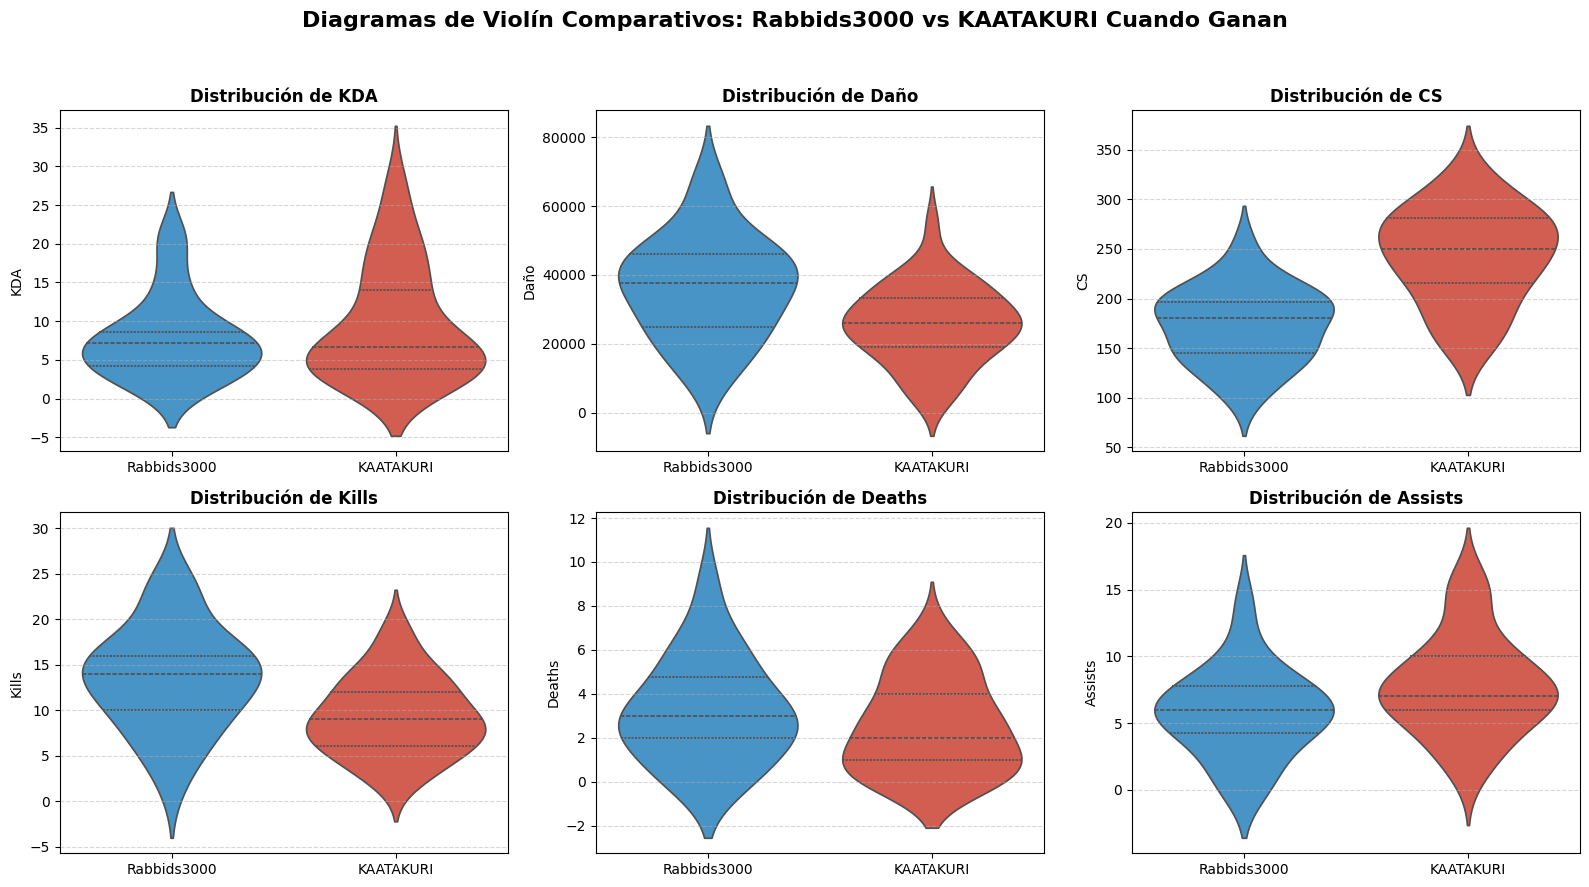

In [47]:
cols_analizar = ['KDA', 'Daño', 'CS', 'Kills', 'Deaths', 'Assists']

# 1. CÁLCULO DE DISPERSIÓN PARA TODAS LAS VARIABLES
print("=== MEDIDAS DE DISPERSIÓN (STD, IQR, MAD) ===")

for col in cols_analizar:
    print(f"\nMétrica: {col}")

    # Rabbids3000
    std_r = df_rabbids[col].std()
    iqr_r = df_rabbids[col].quantile(0.75) - df_rabbids[col].quantile(0.25)
    mad_r = robust.scale.mad(df_rabbids[col])

    # KAATAKURI
    std_k = df_katakuri[col].std()
    iqr_k = df_katakuri[col].quantile(0.75) - df_katakuri[col].quantile(0.25)
    mad_k = robust.scale.mad(df_katakuri[col])

    print(f"  Rabbids3000 -> Desv. Estándar: {std_r:.2f} | IQR: {iqr_r:.2f} | MAD: {mad_r:.2f}")
    print(f"  KAATAKURI   -> Desv. Estándar: {std_k:.2f} | IQR: {iqr_k:.2f} | MAD: {mad_k:.2f}")


# 2. GENERACIÓN DE DIAGRAMAS DE VIOLÍN
# Unimos temporalmente los DataFrames para graficarlos lado a lado
df_rabbids['Jugador'] = 'Rabbids3000'
df_katakuri['Jugador'] = 'KAATAKURI'
df_combinado = pd.concat([df_rabbids, df_katakuri], ignore_index=True)
df_combinado = df_combinado[df_combinado['Resultado'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Diagramas de Violín Comparativos: Rabbids3000 vs KAATAKURI Cuando Ganan', fontsize=16, fontweight='bold')

for i, col in enumerate(cols_analizar):
    row, ax_col = divmod(i, 3)
    ax = axes[row, ax_col]

    # Graficar el violín mostrando cuartiles internos
    sns.violinplot(
        x='Jugador',
        y=col,
        data=df_combinado,
        ax=ax,
        palette=['#3498db', '#e74c3c'],
        inner='quartile' # Dibuja líneas punteadas dentro para la mediana y los cuartiles (25% y 75%)
    )

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

=== MEDIDAS DE DISPERSIÓN (STD, IQR, MAD) ===

Métrica: KDA
  Rabbids3000 -> Desv. Estándar: 4.75 | IQR: 5.33 | MAD: 2.70
  KAATAKURI   -> Desv. Estándar: 6.89 | IQR: 5.93 | MAD: 3.52

Métrica: Daño
  Rabbids3000 -> Desv. Estándar: 19380.33 | IQR: 23696.00 | MAD: 17294.55
  KAATAKURI   -> Desv. Estándar: 11080.28 | IQR: 15106.00 | MAD: 10982.38

Métrica: CS
  Rabbids3000 -> Desv. Estándar: 47.26 | IQR: 62.00 | MAD: 48.93
  KAATAKURI   -> Desv. Estándar: 59.65 | IQR: 78.00 | MAD: 60.79

Métrica: Kills
  Rabbids3000 -> Desv. Estándar: 6.27 | IQR: 9.00 | MAD: 5.93
  KAATAKURI   -> Desv. Estándar: 4.66 | IQR: 7.00 | MAD: 5.93

Métrica: Deaths
  Rabbids3000 -> Desv. Estándar: 3.28 | IQR: 5.00 | MAD: 2.97
  KAATAKURI   -> Desv. Estándar: 2.84 | IQR: 4.00 | MAD: 2.97

Métrica: Assists
  Rabbids3000 -> Desv. Estándar: 4.60 | IQR: 4.00 | MAD: 2.97
  KAATAKURI   -> Desv. Estándar: 3.81 | IQR: 5.00 | MAD: 4.45


/tmp/ipykernel_2612/881472662.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/881472662.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/881472662.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/881472662.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipykernel_2612/881472662.py:38: FutureWarni

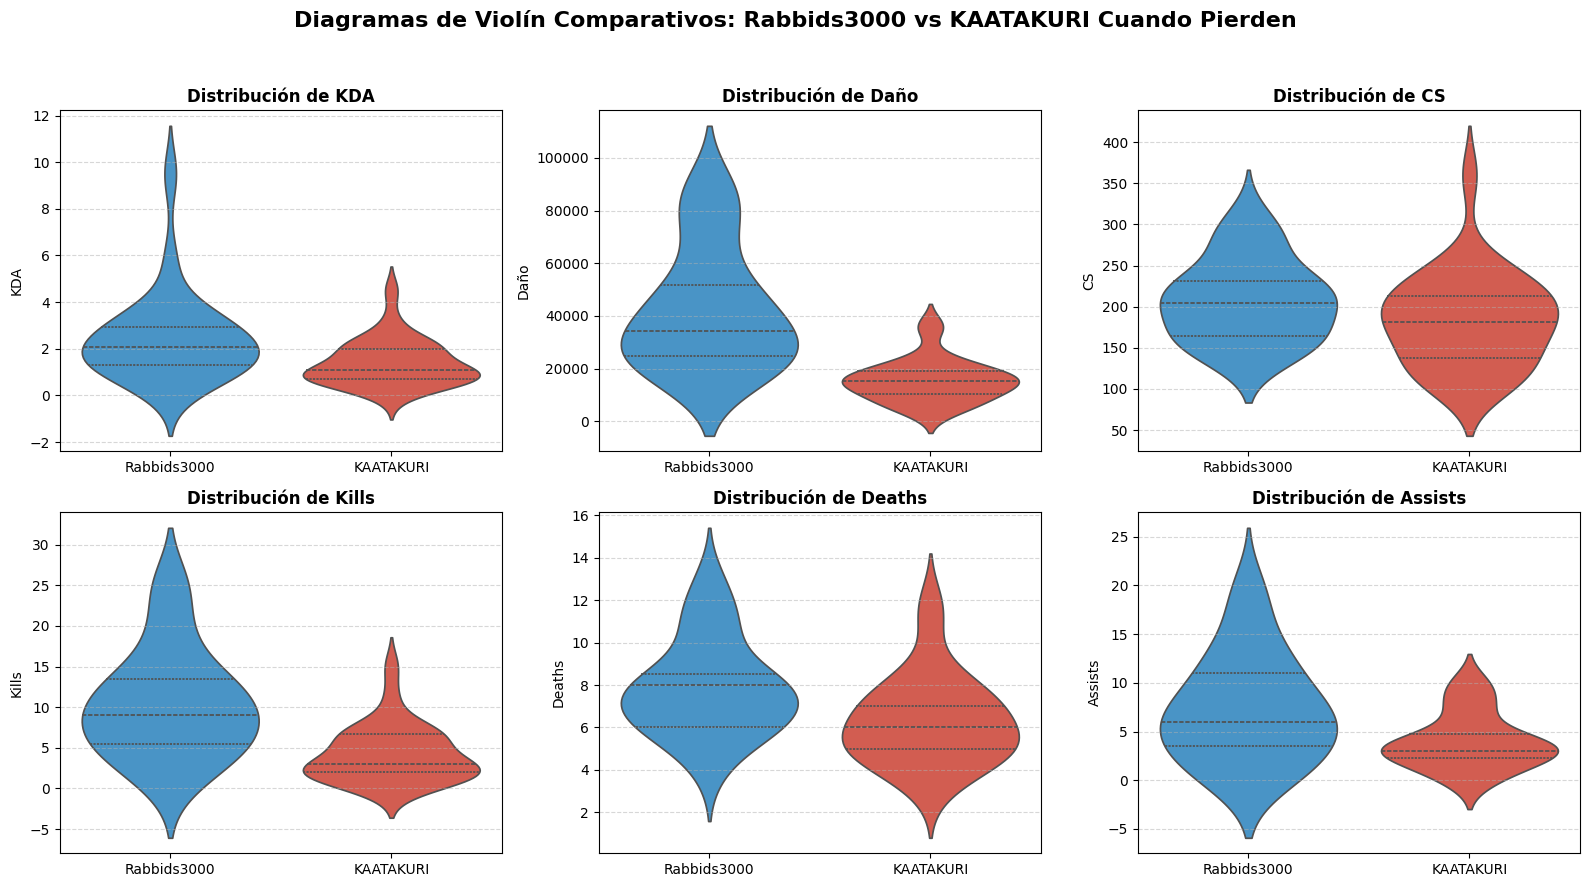

In [49]:
cols_analizar = ['KDA', 'Daño', 'CS', 'Kills', 'Deaths', 'Assists']

# 1. CÁLCULO DE DISPERSIÓN PARA TODAS LAS VARIABLES
print("=== MEDIDAS DE DISPERSIÓN (STD, IQR, MAD) ===")

for col in cols_analizar:
    print(f"\nMétrica: {col}")

    # Rabbids3000
    std_r = df_rabbids[col].std()
    iqr_r = df_rabbids[col].quantile(0.75) - df_rabbids[col].quantile(0.25)
    mad_r = robust.scale.mad(df_rabbids[col])

    # KAATAKURI
    std_k = df_katakuri[col].std()
    iqr_k = df_katakuri[col].quantile(0.75) - df_katakuri[col].quantile(0.25)
    mad_k = robust.scale.mad(df_katakuri[col])

    print(f"  Rabbids3000 -> Desv. Estándar: {std_r:.2f} | IQR: {iqr_r:.2f} | MAD: {mad_r:.2f}")
    print(f"  KAATAKURI   -> Desv. Estándar: {std_k:.2f} | IQR: {iqr_k:.2f} | MAD: {mad_k:.2f}")


# 2. GENERACIÓN DE DIAGRAMAS DE VIOLÍN
# Unimos temporalmente los DataFrames para graficarlos lado a lado
df_rabbids['Jugador'] = 'Rabbids3000'
df_katakuri['Jugador'] = 'KAATAKURI'
df_combinado = pd.concat([df_rabbids, df_katakuri], ignore_index=True)
df_combinado = df_combinado[df_combinado['Resultado'] == 0]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Diagramas de Violín Comparativos: Rabbids3000 vs KAATAKURI Cuando Pierden', fontsize=16, fontweight='bold')

for i, col in enumerate(cols_analizar):
    row, ax_col = divmod(i, 3)
    ax = axes[row, ax_col]

    # Graficar el violín mostrando cuartiles internos
    sns.violinplot(
        x='Jugador',
        y=col,
        data=df_combinado,
        ax=ax,
        palette=['#3498db', '#e74c3c'],
        inner='quartile' # Dibuja líneas punteadas dentro para la mediana y los cuartiles (25% y 75%)
    )

    ax.set_title(f'Distribución de {col}', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(col)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()